In [1]:
import pandas as pd

df=pd.read_csv("weather_football_decision_tree.csv")
print(df)

     Outlook Temperature Humidity    Wind Play_Football
0      Sunny         Hot     High    Weak            No
1      Sunny         Hot     High  Strong            No
2   Overcast         Hot     High    Weak           Yes
3       Rain        Mild     High    Weak           Yes
4       Rain        Cool   Normal    Weak           Yes
5       Rain        Cool   Normal  Strong            No
6   Overcast        Cool   Normal  Strong           Yes
7      Sunny        Mild     High    Weak            No
8      Sunny        Cool   Normal    Weak           Yes
9       Rain        Mild   Normal    Weak           Yes
10     Sunny        Mild   Normal  Strong           Yes
11  Overcast        Mild     High  Strong           Yes
12  Overcast         Hot   Normal    Weak           Yes
13      Rain        Mild     High  Strong            No
14     Sunny        Cool     High  Strong            No
15  Overcast        Cool     High    Weak           Yes
16      Rain         Hot   Normal    Weak       

In [2]:
df.head()

,Outlook,Temperature,Humidity,Wind,Play_Football
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Outlook        20 non-null     object
 1   Temperature    20 non-null     object
 2   Humidity       20 non-null     object
 3   Wind           20 non-null     object
 4   Play_Football  20 non-null     object
dtypes: object(5)
memory usage: 932.0+ bytes


In [4]:
df.shape

(20, 5)

In [5]:
df.nunique()

Outlook          3
Temperature      3
Humidity         2
Wind             2
Play_Football    2
dtype: int64

In [8]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Outlook"] = le.fit_transform(df["Outlook"])
df["Temperature"] = le.fit_transform(df["Temperature"])
df["Humidity"] = le.fit_transform(df["Humidity"])
df["Wind"] = le.fit_transform(df["Wind"])
df["Play_Football"] = le.fit_transform(df["Play_Football"])

df.head()

,Outlook,Temperature,Humidity,Wind,Play_Football
0,2,1,0,1,0
1,2,1,0,0,0
2,0,1,0,1,1
3,1,2,0,1,1
4,1,0,1,1,1


In [9]:
X = df.drop("Play_Football", axis=1)

y = df["Play_Football"]

In [ ]:
X = df.drop("Play_Football", axis=1)

y = df["Play_Football"]


from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()

model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [ ]:

y_pred = model.predict(X_test)

print(y_pred)

[0 1 1 0]


In [ ]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(y_pred)
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 1.0


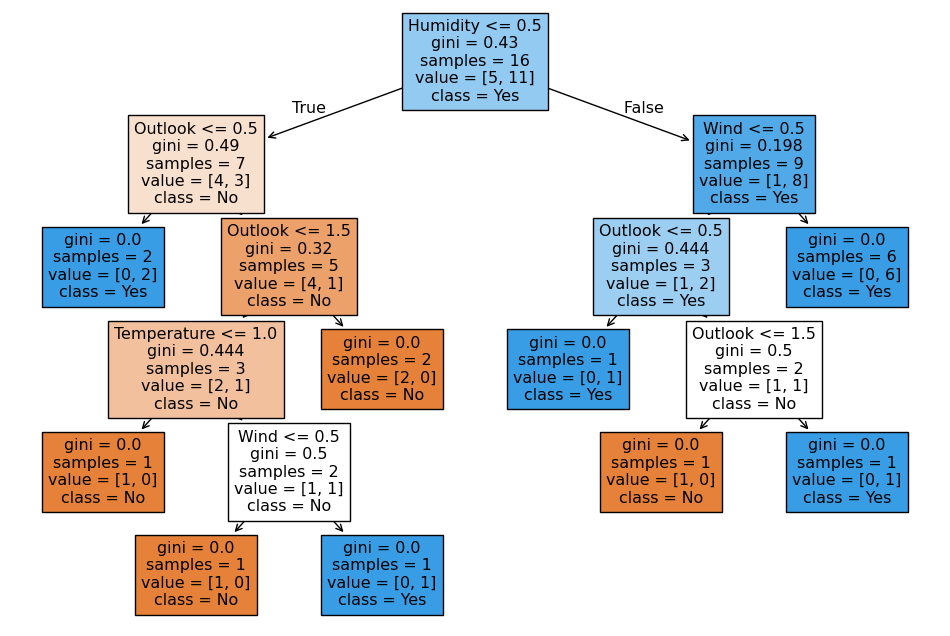

In [14]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["No","Yes"],
    filled=True
)

plt.show()

In [ ]:
def play_football(outlook, temperature, humidity, wind):
    data = [[outlook, temperature, humidity, wind]]
    prediction = model.predict(data)
    if prediction[0] == 1:
        return "Yes, Football Khelo."
    else:
        return "No, Football Mat Khelo."

In [16]:
play_football(2, 1, 1, 1)

c:\Users\Vishnu\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


'Yes, Football Khelo.'

In [17]:
import math

# Number of Yes and No records
yes = 6
no = 4

# Total records
total = yes + no
p_yes = yes / total
p_no = no / total

# Entropy Formula
entropy = -(p_yes * math.log2(p_yes) + p_no * math.log2(p_no))

print("Probability of Yes :", p_yes)
print("Probability of No  :", p_no)
print("log2(Yes)          :", math.log2(p_yes))
print("log2(No)           :", math.log2(p_no))
print("Entropy            :", round(entropy, 4))

Probability of Yes : 0.6
Probability of No  : 0.4
log2(Yes)          : -0.7369655941662062
log2(No)           : -1.3219280948873622
Entropy            : 0.971


In [62]:
import pandas as pd
df=pd.read_csv("customer_product_purchase_decision_tree.csv")

In [63]:
df

,Gender,Age,Occupation,Income,Visited_Website,Purchased_Product
0,Male,22,Student,Low,No,No
1,Female,30,Private,Medium,Yes,Yes
2,Male,45,Business,High,Yes,Yes
3,Female,27,Student,Low,Yes,Yes
4,Male,35,Private,Medium,No,No
5,Female,40,Government,High,Yes,Yes
6,Male,29,Business,Medium,Yes,Yes
7,Female,24,Student,Low,No,No
8,Male,50,Business,High,Yes,Yes
9,Female,33,Private,Medium,Yes,Yes


In [64]:
df.shape

(20, 6)

In [65]:
df.head()

,Gender,Age,Occupation,Income,Visited_Website,Purchased_Product
0,Male,22,Student,Low,No,No
1,Female,30,Private,Medium,Yes,Yes
2,Male,45,Business,High,Yes,Yes
3,Female,27,Student,Low,Yes,Yes
4,Male,35,Private,Medium,No,No


In [66]:
from sklearn.preprocessing import LabelEncoder

gender_encoder = LabelEncoder()
occupation_encoder = LabelEncoder()
income_encoder = LabelEncoder()
website_encoder = LabelEncoder()
target_encoder = LabelEncoder()

df["Gender"] = gender_encoder.fit_transform(df["Gender"])
df["Occupation"] = occupation_encoder.fit_transform(df["Occupation"])
df["Income"] = income_encoder.fit_transform(df["Income"])
df["Visited_Website"] = website_encoder.fit_transform(df["Visited_Website"])

df["Purchased_Product"] = target_encoder.fit_transform(df["Purchased_Product"])

In [67]:
X = df[['Gender','Occupation','Income','Visited_Website']]
y = df["Purchased_Product"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

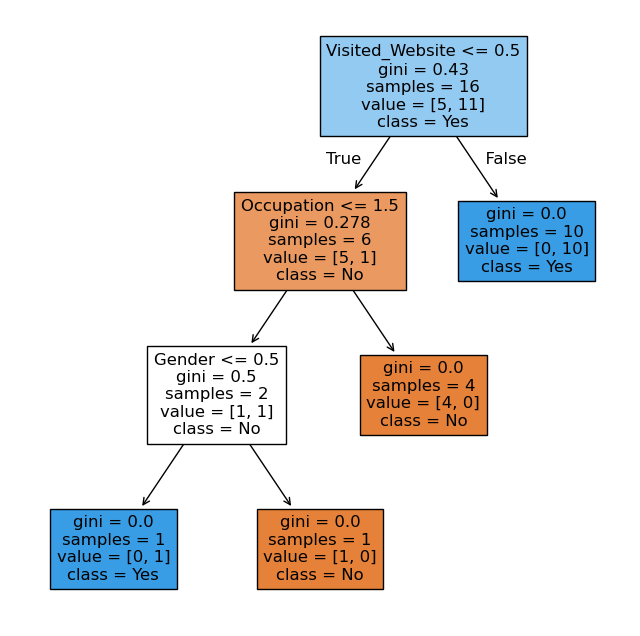

In [68]:

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["No","Yes"],
    filled=True
)

plt.show()

In [69]:
df.head()

,Gender,Age,Occupation,Income,Visited_Website,Purchased_Product
0,1,22,3,1,0,0
1,0,30,2,2,1,1
2,1,45,0,0,1,1
3,0,27,3,1,1,1
4,1,35,2,2,0,0


In [70]:
def predict_customer(Gender,Occupation,Income,Visited_Website):
    data = [[Gender,Occupation,Income,Visited_Website]]
    prediction = model.predict(data)
    if prediction[0] == 1:
        return "Yes, Customer Visited Again."
    else:
        return "No."

In [71]:
y_pred

array([0, 1, 1, 1])

In [72]:
df.head()

,Gender,Age,Occupation,Income,Visited_Website,Purchased_Product
0,1,22,3,1,0,0
1,0,30,2,2,1,1
2,1,45,0,0,1,1
3,0,27,3,1,1,1
4,1,35,2,2,0,0


In [ ]:
def predict_purchase(gender, occupation, income, website):
    gender = gender_encoder.transform([gender])[0]
    occupation = occupation_encoder.transform([occupation])[0]
    income = income_encoder.transform([income])[0]
    website = website_encoder.transform([website])[0]
    prediction = model.predict([[gender, occupation, income, website]])
    result = target_encoder.inverse_transform(prediction)
    return result[0]

In [81]:
output=predict_purchase(
    gender="Female",
    occupation='Business',
    income='High',
    website='No'
)


c:\Users\Vishnu\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [79]:
output

'No'

In [82]:
# Load Data
df=pd.read_csv(r"C:\Users\Vishnu\Desktop\Python_Evening\Ecommerce_Customer_Dataset_1000.csv")

In [83]:
df

,Customer_ID,Gender,Age,City,Occupation,Education,Marital_Status,Income,Previous_Purchases,Discount_Offered(%),Product_Category,Time_Spent_On_Website(min),Added_To_Cart,Payment_Mode,Loyalty_Score,Purchased_Product
0,CUST0001,Male,58,Delhi,Government,Diploma,Single,Low,3,50,Electronics,38,No,UPI,3,No
1,CUST0002,Male,23,Hyderabad,Freelancer,High School,Single,High,20,50,Home,15,No,Net Banking,35,Yes
2,CUST0003,Male,18,Chennai,Government,Graduate,Single,Low,10,5,Electronics,25,Yes,Debit Card,44,Yes
3,CUST0004,Female,56,Delhi,Business,High School,Married,Low,17,20,Beauty,41,No,Net Banking,24,Yes
4,CUST0005,Male,22,Hyderabad,Government,High School,Single,Low,12,20,Home,41,No,Credit Card,47,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,CUST0996,Male,57,Lucknow,Freelancer,Post Graduate,Single,Low,10,25,Electronics,10,Yes,COD,65,Yes
996,CUST0997,Female,23,Kolkata,Business,Post Graduate,Single,Low,8,5,Beauty,59,No,UPI,24,No
997,CUST0998,Female,54,Kolkata,Freelancer,Diploma,Single,Medium,18,40,Fashion,49,No,Debit Card,95,Yes
998,CUST0999,Female,29,Lucknow,Student,Post Graduate,Single,High,9,20,Electronics,27,Yes,UPI,100,Yes


In [84]:
df.shape

(1000, 16)

In [85]:
df.head()

,Customer_ID,Gender,Age,City,Occupation,Education,Marital_Status,Income,Previous_Purchases,Discount_Offered(%),Product_Category,Time_Spent_On_Website(min),Added_To_Cart,Payment_Mode,Loyalty_Score,Purchased_Product
0,CUST0001,Male,58,Delhi,Government,Diploma,Single,Low,3,50,Electronics,38,No,UPI,3,No
1,CUST0002,Male,23,Hyderabad,Freelancer,High School,Single,High,20,50,Home,15,No,Net Banking,35,Yes
2,CUST0003,Male,18,Chennai,Government,Graduate,Single,Low,10,5,Electronics,25,Yes,Debit Card,44,Yes
3,CUST0004,Female,56,Delhi,Business,High School,Married,Low,17,20,Beauty,41,No,Net Banking,24,Yes
4,CUST0005,Male,22,Hyderabad,Government,High School,Single,Low,12,20,Home,41,No,Credit Card,47,Yes


In [86]:
df.isnull().sum()

Customer_ID                   0
Gender                        0
Age                           0
City                          0
Occupation                    0
Education                     0
Marital_Status                0
Income                        0
Previous_Purchases            0
Discount_Offered(%)           0
Product_Category              0
Time_Spent_On_Website(min)    0
Added_To_Cart                 0
Payment_Mode                  0
Loyalty_Score                 0
Purchased_Product             0
dtype: int64

In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Customer_ID                 1000 non-null   object
 1   Gender                      1000 non-null   object
 2   Age                         1000 non-null   int64 
 3   City                        1000 non-null   object
 4   Occupation                  1000 non-null   object
 5   Education                   1000 non-null   object
 6   Marital_Status              1000 non-null   object
 7   Income                      1000 non-null   object
 8   Previous_Purchases          1000 non-null   int64 
 9   Discount_Offered(%)         1000 non-null   int64 
 10  Product_Category            1000 non-null   object
 11  Time_Spent_On_Website(min)  1000 non-null   int64 
 12  Added_To_Cart               1000 non-null   object
 13  Payment_Mode                1000 non-null   objec

In [88]:
df.nunique()

Customer_ID                   1000
Gender                           2
Age                             43
City                            10
Occupation                       5
Education                        4
Marital_Status                   2
Income                           3
Previous_Purchases              21
Discount_Offered(%)              9
Product_Category                 7
Time_Spent_On_Website(min)      60
Added_To_Cart                    2
Payment_Mode                     5
Loyalty_Score                  101
Purchased_Product                2
dtype: int64

In [89]:
df.drop('Customer_ID',axis=1,inplace=True)

In [90]:
df.isnull().sum()

Gender                        0
Age                           0
City                          0
Occupation                    0
Education                     0
Marital_Status                0
Income                        0
Previous_Purchases            0
Discount_Offered(%)           0
Product_Category              0
Time_Spent_On_Website(min)    0
Added_To_Cart                 0
Payment_Mode                  0
Loyalty_Score                 0
Purchased_Product             0
dtype: int64

In [91]:
df.nunique()

Gender                          2
Age                            43
City                           10
Occupation                      5
Education                       4
Marital_Status                  2
Income                          3
Previous_Purchases             21
Discount_Offered(%)             9
Product_Category                7
Time_Spent_On_Website(min)     60
Added_To_Cart                   2
Payment_Mode                    5
Loyalty_Score                 101
Purchased_Product               2
dtype: int64

In [92]:
df.columns

Index(['Gender', 'Age', 'City', 'Occupation', 'Education', 'Marital_Status',
       'Income', 'Previous_Purchases', 'Discount_Offered(%)',
       'Product_Category', 'Time_Spent_On_Website(min)', 'Added_To_Cart',
       'Payment_Mode', 'Loyalty_Score', 'Purchased_Product'],
      dtype='object')

In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Gender                      1000 non-null   object
 1   Age                         1000 non-null   int64 
 2   City                        1000 non-null   object
 3   Occupation                  1000 non-null   object
 4   Education                   1000 non-null   object
 5   Marital_Status              1000 non-null   object
 6   Income                      1000 non-null   object
 7   Previous_Purchases          1000 non-null   int64 
 8   Discount_Offered(%)         1000 non-null   int64 
 9   Product_Category            1000 non-null   object
 10  Time_Spent_On_Website(min)  1000 non-null   int64 
 11  Added_To_Cart               1000 non-null   object
 12  Payment_Mode                1000 non-null   object
 13  Loyalty_Score               1000 non-null   int64

In [95]:
encoders={}
for column in df.columns:
    if df[column].dtype=='object':
        encoder=LabelEncoder()
        df[column]=encoder.fit_transform(df[column])

        encoders[column]=encoder

print(df.head())

    

   Gender  Age  City  Occupation  Education  Marital_Status  Income  \
0       1   58     3           2          0               1       1   
1       1   23     4           1          2               1       0   
2       1   18     2           2          1               1       1   
3       0   56     3           0          2               0       1   
4       1   22     4           2          2               1       1   

   Previous_Purchases  Discount_Offered(%)  Product_Category  \
0                   3                   50                 2   
1                  20                   50                 5   
2                  10                    5                 2   
3                  17                   20                 0   
4                  12                   20                 5   

   Time_Spent_On_Website(min)  Added_To_Cart  Payment_Mode  Loyalty_Score  \
0                          38              0             4              3   
1                          15     

In [96]:
df

,Gender,Age,City,Occupation,Education,Marital_Status,Income,Previous_Purchases,Discount_Offered(%),Product_Category,Time_Spent_On_Website(min),Added_To_Cart,Payment_Mode,Loyalty_Score,Purchased_Product
0,1,58,3,2,0,1,1,3,50,2,38,0,4,3,0
1,1,23,4,1,2,1,0,20,50,5,15,0,3,35,1
2,1,18,2,2,1,1,1,10,5,2,25,1,2,44,1
3,0,56,3,0,2,0,1,17,20,0,41,0,3,24,1
4,1,22,4,2,2,1,1,12,20,5,41,0,1,47,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1,57,7,1,3,1,1,10,25,2,10,1,0,65,1
996,0,23,6,0,3,1,1,8,5,0,59,0,4,24,0
997,0,54,6,1,0,1,2,18,40,3,49,0,2,95,1
998,0,29,7,4,3,1,0,9,20,2,27,1,4,100,1


In [97]:
X = df.drop("Purchased_Product", axis=1)

In [98]:
X

,Gender,Age,City,Occupation,Education,Marital_Status,Income,Previous_Purchases,Discount_Offered(%),Product_Category,Time_Spent_On_Website(min),Added_To_Cart,Payment_Mode,Loyalty_Score
0,1,58,3,2,0,1,1,3,50,2,38,0,4,3
1,1,23,4,1,2,1,0,20,50,5,15,0,3,35
2,1,18,2,2,1,1,1,10,5,2,25,1,2,44
3,0,56,3,0,2,0,1,17,20,0,41,0,3,24
4,1,22,4,2,2,1,1,12,20,5,41,0,1,47
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1,57,7,1,3,1,1,10,25,2,10,1,0,65
996,0,23,6,0,3,1,1,8,5,0,59,0,4,24
997,0,54,6,1,0,1,2,18,40,3,49,0,2,95
998,0,29,7,4,3,1,0,9,20,2,27,1,4,100


In [99]:
y = df["Purchased_Product"]

In [100]:
y

0      0
1      1
2      1
3      1
4      1
      ..
995    1
996    0
997    1
998    1
999    0
Name: Purchased_Product, Length: 1000, dtype: int64

In [101]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42

)